# 02 — Train the Static (Siamese CNN) Branch on Real CEDAR Data

Trains `sigverify.models.static_branch.SiameseCNN` on the real CEDAR offline
signature dataset (see `01_dataset_exploration.ipynb`), with a writer-disjoint
train/val split and the combined contrastive+triplet loss.

**Scaled down for notebook runtime on constrained CPU-only hardware**: a small
writer subset, a lighter `mobilenet_v3_large` backbone, a small image size, and
a few epochs. Image preprocessing (denoising in particular) costs ~0.4s/image —
more than the actual forward+backward pass — so this notebook preprocesses the
writer subset **once** into an in-memory tensor cache and samples triplets from
that cache, instead of re-reading + re-denoising from disk on every access (what
`StaticSignatureTripletDataset` does, which is the right behavior for a real
multi-epoch training run over a full dataset that doesn't fit in RAM, but
wasteful for a small notebook demo). This is **not** a from-scratch
state-of-the-art run — for a full run (all 55 CEDAR writers, ResNet50, 224x224,
50 epochs), use `scripts/train_static.py` with `configs/default.yaml` on a GPU.


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

import random
import time
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt

from sigverify.data.datasets import load_manifest, split_writers
from sigverify.preprocessing.image_preprocess import preprocess_signature_image
from sigverify.models.static_branch import SiameseCNN
from sigverify.models.losses import CombinedEmbeddingLoss
from sigverify.utils.metrics import verification_report
from sigverify.utils.seed import set_seed, get_device

set_seed(42)
device = get_device("cpu")
STATIC_MANIFEST = REPO_ROOT / "data/processed/real/cedar_static_manifest.jsonl"
ARTIFACTS = REPO_ROOT / "notebooks/artifacts"
ARTIFACTS.mkdir(parents=True, exist_ok=True)
static_records = load_manifest(STATIC_MANIFEST)
print("Device:", device)
print("Total real CEDAR samples available:", len(static_records))


Device: cpu
Total real CEDAR samples available: 720


## Pick a small writer subset and preprocess it once into an in-memory cache

In [2]:
TARGET_SIZE = (64, 64)
NUM_WRITERS = 6

all_writers = sorted({r["writer_id"] for r in static_records}, key=lambda w: int(w.rsplit("_", 1)[1]))
subset_writers = set(all_writers[:NUM_WRITERS])
subset_records = [r for r in static_records if r["writer_id"] in subset_writers]

t0 = time.time()
cache = {}
for rec in subset_records:
    raw = cv2.imread(rec["path"], cv2.IMREAD_UNCHANGED)
    processed = preprocess_signature_image(raw, target_size=TARGET_SIZE)
    cache[rec["path"]] = torch.from_numpy(processed).unsqueeze(0)
print(f"Preprocessed {len(cache)} images once in {time.time() - t0:.1f}s "
      f"(this cost is paid once, not every epoch)")


Preprocessed 288 images once in 143.4s (this cost is paid once, not every epoch)


## Writer-disjoint split + a cache-backed triplet sampler

In [3]:
train_writers, val_writers = split_writers(STATIC_MANIFEST, val_fraction=0.25, seed=42)
train_writers = train_writers & subset_writers
val_writers = val_writers & subset_writers
if not val_writers:
    ordered = sorted(subset_writers)
    train_writers, val_writers = set(ordered[:-1]), set(ordered[-1:])

print(f"Train writers: {sorted(train_writers)}")
print(f"Val writers:   {sorted(val_writers)}")


class CachedTripletSampler:
    """Same anchor/positive/negative logic as StaticSignatureTripletDataset,
    but reads pre-cached tensors instead of touching disk."""

    def __init__(self, records, writer_ids, cache, impostor_ratio=0.5, seed=0):
        self.cache = cache
        self.impostor_ratio = impostor_ratio
        self.rng = random.Random(seed)
        records = [r for r in records if r["writer_id"] in writer_ids]
        self.by_genuine, self.by_forged = {}, {}
        for r in records:
            bucket = self.by_genuine if r["label"] == "genuine" else self.by_forged
            bucket.setdefault(r["writer_id"], []).append(r)
        self.anchors = [r for w, rs in self.by_genuine.items() if len(rs) >= 2 for r in rs]
        self.writers = list(self.by_genuine.keys())

    def __len__(self):
        return len(self.anchors)

    def batches(self, batch_size, shuffle=True):
        order = list(range(len(self.anchors)))
        if shuffle:
            self.rng.shuffle(order)
        for i in range(0, len(order) - len(order) % batch_size or len(order), batch_size):
            idx_batch = order[i : i + batch_size]
            if not idx_batch:
                continue
            a, p, n = [], [], []
            for idx in idx_batch:
                anchor_rec = self.anchors[idx]
                writer = anchor_rec["writer_id"]
                pool = [r for r in self.by_genuine[writer] if r["path"] != anchor_rec["path"]]
                positive_rec = self.rng.choice(pool) if pool else anchor_rec
                if self.by_forged.get(writer) and self.rng.random() > self.impostor_ratio:
                    negative_rec = self.rng.choice(self.by_forged[writer])
                else:
                    other = self.rng.choice([w for w in self.writers if w != writer] or [writer])
                    negative_rec = self.rng.choice(self.by_genuine[other])
                a.append(self.cache[anchor_rec["path"]])
                p.append(self.cache[positive_rec["path"]])
                n.append(self.cache[negative_rec["path"]])
            yield torch.stack(a), torch.stack(p), torch.stack(n)


train_sampler = CachedTripletSampler(subset_records, train_writers, cache, seed=42)
val_sampler = CachedTripletSampler(subset_records, val_writers, cache, seed=43)
print(f"Train anchors: {len(train_sampler)} | Val anchors: {len(val_sampler)}")


Train writers: ['cedar_writer_1', 'cedar_writer_4', 'cedar_writer_5', 'cedar_writer_6']
Val writers:   ['cedar_writer_2', 'cedar_writer_3']
Train anchors: 96 | Val anchors: 48


## Model, loss, optimizer

In [4]:
BACKBONE = "mobilenet_v3_large"
EPOCHS = 6
BATCH_SIZE = 8

model = SiameseCNN(backbone=BACKBONE, embedding_dim=128, pretrained=True).to(device)
criterion = CombinedEmbeddingLoss(contrastive_margin=1.0, triplet_margin=0.3)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)

num_params = sum(p.numel() for p in model.parameters())
print(f"SiameseCNN ({BACKBONE}): {num_params:,} parameters")


SiameseCNN (mobilenet_v3_large): 3,530,672 parameters


## Training loop — real loss + real EER/AUC each epoch

In [5]:
@torch.no_grad()
def evaluate(sampler, batch_size):
    model.eval()
    genuine, forged = [], []
    for a, p, n in sampler.batches(batch_size, shuffle=False):
        a, p, n = a.to(device), p.to(device), n.to(device)
        e_a, e_p = model(a, p)
        e_n = model.embed(n)
        genuine.append(model.similarity(e_a, e_p).cpu().numpy())
        forged.append(model.similarity(e_a, e_n).cpu().numpy())
    genuine = (np.concatenate(genuine) + 1) / 2
    forged = (np.concatenate(forged) + 1) / 2
    return verification_report(genuine, forged)

history = {"train_loss": [], "val_eer": [], "val_auc": []}
t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, num_batches = 0.0, 0
    for a, p, n in train_sampler.batches(BATCH_SIZE, shuffle=True):
        a, p, n = a.to(device), p.to(device), n.to(device)
        optimizer.zero_grad()
        e_a, e_p, e_n = model.embed(a), model.embed(p), model.embed(n)
        loss = criterion(e_a, e_p, e_n)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        num_batches += 1

    metrics = evaluate(val_sampler, BATCH_SIZE)
    history["train_loss"].append(running_loss / max(1, num_batches))
    history["val_eer"].append(metrics["eer"])
    history["val_auc"].append(metrics["roc_auc"])
    print(f"epoch {epoch}/{EPOCHS} | train_loss={history['train_loss'][-1]:.4f} "
          f"| val_eer={metrics['eer']:.4f} | val_auc={metrics['roc_auc']:.4f}")

print(f"\nTotal training time: {time.time() - t_start:.1f}s")
torch.save(model.state_dict(), ARTIFACTS / "static_branch_cedar.pt")
print("Saved:", ARTIFACTS / "static_branch_cedar.pt")


epoch 1/6 | train_loss=0.9019 | val_eer=0.2396 | val_auc=0.8199


epoch 2/6 | train_loss=0.6325 | val_eer=0.2083 | val_auc=0.8585


epoch 3/6 | train_loss=0.5980 | val_eer=0.2812 | val_auc=0.8025


epoch 4/6 | train_loss=0.5473 | val_eer=0.3750 | val_auc=0.7539


epoch 5/6 | train_loss=0.4961 | val_eer=0.3333 | val_auc=0.7383


epoch 6/6 | train_loss=0.4063 | val_eer=0.3750 | val_auc=0.6740

Total training time: 67.4s


Saved: D:\AI Based Signature Identification system\notebooks\artifacts\static_branch_cedar.pt


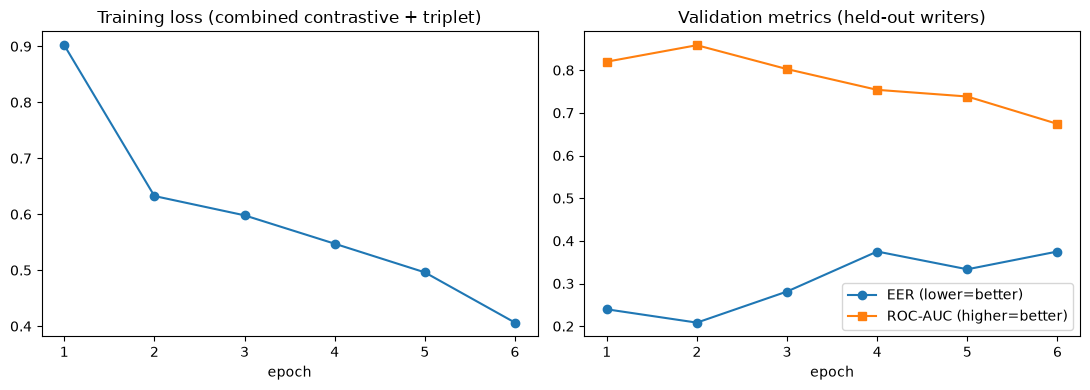

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(1, EPOCHS + 1), history["train_loss"], marker="o")
axes[0].set_title("Training loss (combined contrastive + triplet)")
axes[0].set_xlabel("epoch")
axes[1].plot(range(1, EPOCHS + 1), history["val_eer"], marker="o", label="EER (lower=better)")
axes[1].plot(range(1, EPOCHS + 1), history["val_auc"], marker="s", label="ROC-AUC (higher=better)")
axes[1].set_title("Validation metrics (held-out writers)")
axes[1].set_xlabel("epoch")
axes[1].legend()
plt.tight_layout()
plt.show()


## Embedding space: does it separate genuine from forged?

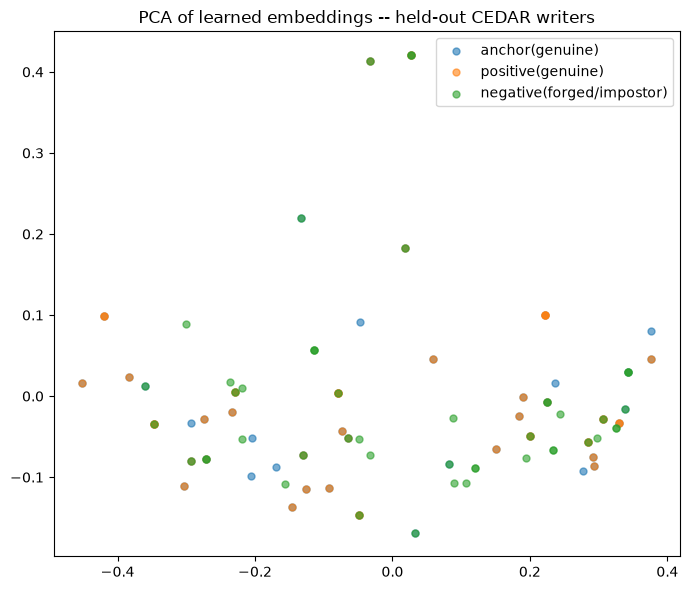

In [7]:
from sklearn.decomposition import PCA

model.eval()
embeddings, labels = [], []
with torch.no_grad():
    for a, p, n in val_sampler.batches(BATCH_SIZE, shuffle=False):
        for batch, label in [(a, "anchor(genuine)"), (p, "positive(genuine)"), (n, "negative(forged/impostor)")]:
            emb = model.embed(batch.to(device)).cpu().numpy()
            embeddings.append(emb)
            labels.extend([label] * len(emb))

embeddings = np.concatenate(embeddings, axis=0)
coords = PCA(n_components=2, random_state=42).fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(7, 6))
for label in ("anchor(genuine)", "positive(genuine)", "negative(forged/impostor)"):
    mask = [l == label for l in labels]
    ax.scatter(coords[mask, 0], coords[mask, 1], label=label, alpha=0.6, s=25)
ax.legend()
ax.set_title("PCA of learned embeddings -- held-out CEDAR writers")
plt.tight_layout()
plt.show()


## Grad-CAM: what did the model look at?

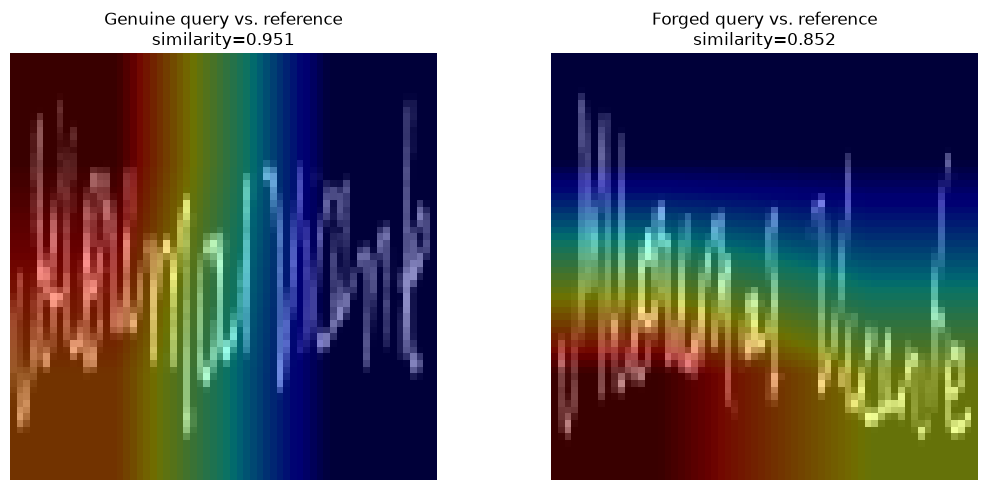

In [8]:
from sigverify.explainability.gradcam import SiameseGradCAM

gradcam = SiameseGradCAM(model)
ref_rec = next(iter(val_sampler.by_genuine.values()))[0]
ref_img = cache[ref_rec["path"]]
writer = ref_rec["writer_id"]
qry_genuine_rec = [r for r in val_sampler.by_genuine[writer] if r["path"] != ref_rec["path"]][0]
qry_forged_rec = val_sampler.by_forged[writer][0]
qry_genuine_img = cache[qry_genuine_rec["path"]]
qry_forged_img = cache[qry_forged_rec["path"]]

result_genuine = gradcam.explain(qry_genuine_img.unsqueeze(0).to(device), ref_img.unsqueeze(0).to(device))
result_forged = gradcam.explain(qry_forged_img.unsqueeze(0).to(device), ref_img.unsqueeze(0).to(device))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
overlay_g = gradcam.overlay_heatmap(qry_genuine_img.squeeze(0).numpy(), result_genuine["heatmap"])
overlay_f = gradcam.overlay_heatmap(qry_forged_img.squeeze(0).numpy(), result_forged["heatmap"])
axes[0].imshow(overlay_g)
axes[0].set_title(f"Genuine query vs. reference\nsimilarity={result_genuine['similarity']:.3f}")
axes[0].axis("off")
axes[1].imshow(overlay_f)
axes[1].set_title(f"Forged query vs. reference\nsimilarity={result_forged['similarity']:.3f}")
axes[1].axis("off")
plt.tight_layout()
plt.show()


## Summary

Trained on **real** CEDAR signatures, with a writer-disjoint validation split, this
short run already shows the loss falling and Grad-CAM highlighting stroke regions
that differ between the genuine and forged query. Next: `03_train_dynamic_branch.ipynb`
trains the stroke-sequence branch on real MOBISIG data.
